# 07 — Simulation and Scenario Testing

This notebook shifts the project from prediction into simulation-driven exploration. In this next iteration, I used simulation to uncover what my models actually believe, and where they break.

Rather than focusing primarily on causal identification, the goal is to use Monte Carlo simulation and structured scenario testing to:

- stress test model behavior under alternative conditions
- evaluate sensitivity to key inputs like starting position and reliability
- uncover where models are stable vs fragile
- identify missing structure in the dataset
- generate ideas for new features, transformations, and modeling approaches

In this sense, simulation is not just a forecasting tool—it is a diagnostic tool.

It provides a way to ask:

**What does the model believe about the world, and where does that belief break down?**

This notebook uses Formula 1 as a controlled environment to explore:
- how race and season outcomes respond to perturbations
- how uncertainty accumulates across a season
- and how model assumptions translate into simulated reality

These insights are not limited to motorsport. They generalize to any system where:
- outcomes are stochastic
- structure is partially observed
- and models must operate under uncertainty

## Predictive Simulation vs Counterfactual Reasoning

This notebook makes use of both predictive simulation and counterfactual scenario testing.

- **Predictive simulation** draws outcomes from the model’s learned distribution
- **Counterfactual scenarios** alter inputs and observe how simulated outcomes change

These exercises can sometimes resemble causal analysis, but they are not equivalent.

A fully causal interpretation would require stronger identification assumptions than are available in this dataset.

Instead, the focus here is:

- understanding model sensitivity
- exploring alternative racing scenarios
- identifying where model assumptions hold or fail

The goal is not to claim definitive causal effects, but to use simulation as a structured way to probe the model and the data.

## Why Simulation Matters in This Project

Up to this point, the project has focused on:
- feature engineering
- model comparison
- validation and stability

Those steps answer an important question:

**How well do the models fit the data?**

Simulation allows us to ask a different question:

**What do these models imply about how the system behaves?**

By simulating alternative scenarios, we can:
- observe how small changes propagate through the system
- identify nonlinear effects that are not obvious from model coefficients
- detect where predictions become unstable
- uncover patterns that suggest missing variables or transformations

In other words, simulation turns static model evaluation into dynamic system exploration.

## Section 1: Data Inputs for Simulation and Setup

- race-level expected finish or probability estimates
- points expectations
- driver / constructor identifiers
- grid / qualifying info
- reliability proxies
- weather flags
- pit-stop shock parameters

-----------------------------------------------------

- predicted finish position
- predicted points
- podium probability
- points probability
- DNF probability if available from prior work

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

from xgboost import XGBRegressor

np.random.seed(42)
pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")

In [2]:
prerace = pd.read_parquet("data_processed/f1_feature_store_prerace.parquet")
master = pd.read_parquet("data_processed/f1_feature_store_master.parquet")

print("prerace shape:", prerace.shape)
print("master shape:", master.shape)

prerace shape: (26759, 49)
master shape: (26759, 103)


In [3]:
original_features = [
    "grid_clean",
    "qualifying_position",
    "driver_avg_finish_last5",
    "driver_points_last5",
    "driver_dnf_rate_last5",
    "driver_avg_grid_last5",
    "constructor_points_last5",
    "constructor_dnf_rate_last5",
    "constructor_avg_finish_last5",
    "driver_standing_points_prerace",
    "driver_standing_position_prerace",
    "driver_standing_wins_prerace",
    "constructor_standing_points_prerace",
    "constructor_standing_position_prerace",
    "constructor_standing_wins_prerace",
    "alt",
    "temp_avg",
    "precipitation",
    "wind_speed",
    "is_wet_race"
]

refined_features = [
    "qualifying_position",
    "driver_avg_finish_last5",
    "driver_dnf_rate_last5",
    "constructor_avg_finish_last5",
    "constructor_dnf_rate_last5",
    "alt",
    "temp_avg",
    "precipitation",
    "wind_speed",
    "is_wet_race"
]

TARGET_SPECS = {
    "finish_position": {
        "label": "Finish Position",
        "type": "regression"
    },
    "points": {
        "label": "Points",
        "type": "regression"
    }
}

DATASET_FEATURES = {
    "original": original_features,
    "refined": refined_features
}

In [4]:
transformed_features = ["precipitation", "wind_speed"]

preprocessor_original = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), original_features)
    ],
    remainder="drop"
)

preprocessor_refined = ColumnTransformer(
    transformers=[
        ("power", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("power", PowerTransformer(method="yeo-johnson")),
            ("scaler", StandardScaler())
        ]), transformed_features),
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), [c for c in refined_features if c not in transformed_features])
    ],
    remainder="drop"
)

ridge_model = Ridge(alpha=1.0)

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

MODEL_REGISTRY = {
    "original": {
        "ridge": Pipeline([
            ("preprocess", preprocessor_original),
            ("model", ridge_model)
        ]),
        "pcr": Pipeline([
            ("preprocess", preprocessor_original),
            ("pca", PCA(n_components=10)),
            ("model", LinearRegression())
        ]),
        "xgboost": Pipeline([
            ("preprocess", preprocessor_original),
            ("model", xgb_model)
        ])
    },
    "refined": {
        "ridge": Pipeline([
            ("preprocess", preprocessor_refined),
            ("model", ridge_model)
        ]),
        "pcr": Pipeline([
            ("preprocess", preprocessor_refined),
            ("pca", PCA(n_components=min(8, len(refined_features)))),
            ("model", LinearRegression())
        ]),
        "xgboost": Pipeline([
            ("preprocess", preprocessor_refined),
            ("model", xgb_model)
        ])
    }
}

## Load Simulation Base Table

Use the cleaned pre-race feature store and model outputs from earlier notebooks as inputs into the simulation framework. What distribution are we simulating from?

In [5]:
BASE_ID_COLS = [
    "year", "round", "raceId", "driverId", "constructorId"
]

SIM_FEATURES = [
    "qualifying_position",
    "grid_clean",
    "driver_avg_finish_last5",
    "driver_dnf_rate_last5",
    "constructor_avg_finish_last5",
    "constructor_dnf_rate_last5",
    "is_wet_race",
    "alt",
    "temp_avg",
    "precipitation",
    "wind_speed"
]

# NEW: include everything required by all datasets
ALL_SIM_COLS = list(set(
    BASE_ID_COLS +
    list(TARGET_SPECS.keys()) +
    original_features +
    refined_features
))

sim_df = prerace[ALL_SIM_COLS].copy()

for col in sim_df.columns:
    sim_df[col] = pd.to_numeric(sim_df[col], errors="coerce")

print(sim_df.shape)
sim_df.head()

(26759, 27)


,precipitation,alt,driver_standing_wins_prerace,constructor_dnf_rate_last5,driver_dnf_rate_last5,driver_standing_points_prerace,constructor_standing_wins_prerace,constructor_standing_points_prerace,year,driverId,finish_position,is_wet_race,constructor_standing_position_prerace,driver_points_last5,constructorId,raceId,constructor_points_last5,grid_clean,constructor_avg_finish_last5,temp_avg,wind_speed,driver_standing_position_prerace,driver_avg_grid_last5,points,driver_avg_finish_last5,round,qualifying_position
0,0.0,10,4.0,0.4,0.2,109.0,8.0,218.0,2008,1,1,0,11.0,25.0,1,18,16.0,1.0,10.4,27.9,23.1,2.0,2.0,10.0,6.6,1,1.0
1,0.0,10,0.0,0.4,0.2,61.0,0.0,101.0,2008,2,2,0,2.0,14.0,2,18,9.0,5.0,10.0,27.9,23.1,5.0,5.8,8.0,7.2,1,5.0
2,0.0,10,0.0,0.2,0.2,20.0,0.0,33.0,2008,3,3,0,4.0,11.0,3,18,5.0,7.0,12.8,27.9,23.1,9.0,10.8,6.0,10.0,1,7.0
3,0.0,10,4.0,0.4,0.2,109.0,0.0,51.0,2008,4,4,0,3.0,30.0,4,18,4.0,11.0,12.8,27.9,23.1,3.0,2.8,5.0,6.0,1,12.0
4,0.0,10,0.0,0.2,0.2,30.0,8.0,218.0,2008,5,5,0,11.0,11.0,1,18,26.0,3.0,6.4,27.9,23.1,7.0,11.4,4.0,8.6,1,3.0


In [6]:
def build_prediction_base(df, target_name, dataset_name, feature_set, model_name, model):
    required_cols = BASE_ID_COLS + feature_set + [target_name]
    missing_cols = [c for c in required_cols if c not in df.columns]

    if missing_cols:
        raise KeyError(
            f"Missing columns for target={target_name}, dataset={dataset_name}, model={model_name}: {missing_cols}"
        )

    model_df = df[required_cols].copy()

    for col in model_df.columns:
        model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

    model_df = model_df.dropna(subset=[target_name]).copy()

    train = model_df[model_df["year"] <= 2021].copy()
    test = model_df[model_df["year"] > 2021].copy()

    X_train = train[feature_set]
    y_train = train[target_name]
    X_test = test[feature_set]
    y_test = test[target_name]

    fitted = clone(model)
    fitted.fit(X_train, y_train)

    train_pred = fitted.predict(X_train)
    test_pred = fitted.predict(X_test)

    train["pred"] = train_pred
    test["pred"] = test_pred

    train["residual"] = train[target_name] - train["pred"]
    test["residual"] = test[target_name] - test["pred"]

    out = pd.concat([train, test], axis=0).copy()
    out["target"] = target_name
    out["dataset"] = dataset_name
    out["model"] = model_name

    resid_std = train["residual"].std()
    out["residual_sd_train"] = resid_std if pd.notna(resid_std) else 1.0

    return out, fitted

In [7]:
prediction_tables = []
fitted_models = {}

for target_name in TARGET_SPECS:
    for dataset_name, feature_set in DATASET_FEATURES.items():
        for model_name, model in MODEL_REGISTRY[dataset_name].items():
            pred_df, fitted_model = build_prediction_base(
                df=sim_df,
                target_name=target_name,
                dataset_name=dataset_name,
                feature_set=feature_set,
                model_name=model_name,
                model=model
            )

            prediction_tables.append(pred_df)
            fitted_models[(target_name, dataset_name, model_name)] = fitted_model

simulation_base = pd.concat(prediction_tables, ignore_index=True)
simulation_base.head()

,year,round,raceId,driverId,constructorId,grid_clean,qualifying_position,driver_avg_finish_last5,driver_points_last5,driver_dnf_rate_last5,driver_avg_grid_last5,constructor_points_last5,constructor_dnf_rate_last5,constructor_avg_finish_last5,driver_standing_points_prerace,driver_standing_position_prerace,driver_standing_wins_prerace,constructor_standing_points_prerace,constructor_standing_position_prerace,constructor_standing_wins_prerace,alt,temp_avg,precipitation,wind_speed,is_wet_race,finish_position,pred,residual,target,dataset,model,residual_sd_train,points
0,2008,1,18,1,1,1.0,1.0,6.6,25.0,0.2,2.0,16.0,0.4,10.4,109.0,2.0,4.0,218.0,11.0,8.0,10,27.9,0.0,23.1,0,1.0,9.196437,-8.196437,finish_position,original,ridge,6.493175,NaN
1,2008,1,18,2,2,5.0,5.0,7.2,14.0,0.2,5.8,9.0,0.4,10.0,61.0,5.0,0.0,101.0,2.0,0.0,10,27.9,0.0,23.1,0,2.0,7.432546,-5.432546,finish_position,original,ridge,6.493175,NaN
2,2008,1,18,3,3,7.0,7.0,10.0,11.0,0.2,10.8,5.0,0.2,12.8,20.0,9.0,0.0,33.0,4.0,0.0,10,27.9,0.0,23.1,0,3.0,10.499223,-7.499223,finish_position,original,ridge,6.493175,NaN
3,2008,1,18,4,4,11.0,12.0,6.0,30.0,0.2,2.8,4.0,0.4,12.8,109.0,3.0,4.0,51.0,3.0,0.0,10,27.9,0.0,23.1,0,4.0,7.599716,-3.599716,finish_position,original,ridge,6.493175,NaN
4,2008,1,18,5,1,3.0,3.0,8.6,11.0,0.2,11.4,26.0,0.2,6.4,30.0,7.0,0.0,218.0,11.0,8.0,10,27.9,0.0,23.1,0,5.0,11.073191,-6.073191,finish_position,original,ridge,6.493175,NaN


In [8]:
simulation_base["pred_points_clipped"] = simulation_base["pred"].where(
    simulation_base["target"] != "points",
    simulation_base["pred"].clip(lower=0)
)

simulation_base["baseline_dnf_prob"] = (
    0.5 * simulation_base["driver_dnf_rate_last5"].fillna(0) +
    0.5 * simulation_base["constructor_dnf_rate_last5"].fillna(0)
).clip(0, 1)

simulation_base["baseline_podium_prob_proxy"] = np.where(
    simulation_base["target"] == "finish_position",
    1 / (1 + np.exp((simulation_base["pred"] - 3))),
    np.nan
)

simulation_base["baseline_points_prob_proxy"] = np.where(
    simulation_base["target"] == "finish_position",
    1 / (1 + np.exp((simulation_base["pred"] - 10))),
    np.where(
        simulation_base["target"] == "points",
        1 / (1 + np.exp(-(simulation_base["pred"] - 1))),
        np.nan
    )
)

In [9]:
import sys
print(sys.executable)

/Users/paigeblackstone/Documents/GitHub/f1-worldchamp/.venv/bin/python


## Section 2 Monte Carlo Simulation Design

**Monte Carlo Simulation: Season Outcomes Under Reliability Assumptions**

This section simulates season standings under different reliability assumptions by altering DNF probabilities and re-running race outcomes thousands of times.

Scenarios:
- baseline
- +10% reliability improvement for constructor
- -10% reliability
- selective reliability shock to one driver

Outputs:
- championship probability
- average constructor points
- standing distributions

If reliability improves or worsens for a team, how do season standings change?

For each race-driver:

**Monte Carlo: Reliability as a Structural Stress Test**

This simulation examines how sensitive model outcomes are to reliability assumptions.

Rather than treating reliability purely as a causal driver, this section uses it as a stress test:

- How much do rare events (DNFs) influence season outcomes?
- Do models understate or overstate the impact of reliability?
- How does uncertainty compound across multiple races?

This helps reveal:
- whether the model is overly dependent on clean finishes
- whether tail risks are properly captured
- whether reliability should be modeled more explicitly

possible insights:
- maybe you need better DNF modeling
- maybe binary outcomes need separate treatment
- maybe survival / hazard modeling could be added later

In [10]:
POINTS_MAP = {
    1: 25, 2: 18, 3: 15, 4: 12, 5: 10,
    6: 8, 7: 6, 8: 4, 9: 2, 10: 1
}

def finish_to_points(pos):
    pos = int(np.round(pos))
    return POINTS_MAP.get(pos, 0)

In [11]:
def simulate_race_outcome(row, rng):
    if rng.random() < row["baseline_dnf_prob"]:
        return {
            "sim_finish_position": 20,
            "sim_points": 0,
            "sim_dnf": 1
        }

    pred = row["pred"]
    sd = row["residual_sd_train"] if pd.notna(row["residual_sd_train"]) else 1.0
    sim_finish = np.clip(np.round(rng.normal(pred, sd)), 1, 20)

    if row["target"] == "points":
        sim_points = max(0, rng.normal(pred, sd))
    else:
        sim_points = finish_to_points(sim_finish)

    return {
        "sim_finish_position": sim_finish,
        "sim_points": sim_points,
        "sim_dnf": 0
    }

In [12]:
def apply_reliability_scenario(df, scenario_name, constructor_id=None, driver_id=None, delta=0.0):
    out = df.copy()

    if scenario_name == "baseline":
        return out

    if constructor_id is not None:
        mask = out["constructorId"] == constructor_id
        out.loc[mask, "baseline_dnf_prob"] = (
            out.loc[mask, "baseline_dnf_prob"] * (1 + delta)
        ).clip(0, 1)

    if driver_id is not None:
        mask = out["driverId"] == driver_id
        out.loc[mask, "baseline_dnf_prob"] = (
            out.loc[mask, "baseline_dnf_prob"] * (1 + delta)
        ).clip(0, 1)

    return out

In [13]:
def simulate_season(df, n_sims=1000, seed=42):
    rng = np.random.default_rng(seed)
    sim_rows = []

    season_df = df.copy()

    for sim in range(n_sims):
        for _, row in season_df.iterrows():
            outcome = simulate_race_outcome(row, rng)
            sim_rows.append({
                "sim": sim,
                "year": row["year"],
                "raceId": row["raceId"],
                "driverId": row["driverId"],
                "constructorId": row["constructorId"],
                "target": row["target"],
                "dataset": row["dataset"],
                "model": row["model"],
                **outcome
            })

    return pd.DataFrame(sim_rows)

In [14]:
baseline_subset = simulation_base[
    (simulation_base["target"] == "finish_position") &
    (simulation_base["dataset"] == "refined") &
    (simulation_base["model"] == "xgboost") &
    (simulation_base["year"] >= 2022)
].copy()

baseline_sim = simulate_season(baseline_subset, n_sims=250, seed=42)
baseline_sim.head()

,sim,year,raceId,driverId,constructorId,target,dataset,model,sim_finish_position,sim_points,sim_dnf
0,0,2022,1074,844,6,finish_position,refined,xgboost,1.0,25,0
1,0,2022,1074,832,6,finish_position,refined,xgboost,12.0,0,0
2,0,2022,1074,1,131,finish_position,refined,xgboost,20.0,0,1
3,0,2022,1074,847,131,finish_position,refined,xgboost,10.0,1,0
4,0,2022,1074,825,210,finish_position,refined,xgboost,12.0,0,0


In [15]:
reliability_scenarios = [
    {"scenario": "baseline", "constructor_id": None, "driver_id": None, "delta": 0.0},
    {"scenario": "constructor_plus_10pct", "constructor_id": None, "driver_id": None, "delta": -0.10},
    {"scenario": "constructor_minus_10pct", "constructor_id": None, "driver_id": None, "delta": 0.10}
]

# choose a constructor later or parameterize interactively

In [16]:
constructor_standings = (
    baseline_sim
    .groupby(["sim", "constructorId"], as_index=False)
    .agg(total_points=("sim_points", "sum"))
)

constructor_standings["final_rank"] = (
    constructor_standings
    .groupby("sim")["total_points"]
    .rank(method="dense", ascending=False)
)
constructor_standings.head()

,sim,constructorId,total_points,final_rank
0,0,1,821,4.0
1,0,3,238,8.0
2,0,6,1180,2.0
3,0,9,1270,1.0
4,0,15,79,11.0


## Counterfactual Grid Positions: Sensitivity to Starting Conditions

This section tests how sensitive model outcomes are to changes in starting position.

The question we want to answer is:

how are podium and points probabilities changed when starting position is shifted upward or downward, while holding other pre-race features fixed?

Rather than interpreting this strictly as a causal estimate, the goal is to understand:

- how much the model relies on grid position
- whether that relationship is linear or nonlinear
- where diminishing returns begin

By shifting starting positions and re-simulating outcomes, we can observe:
- marginal gains in expected points
- nonlinear effects near the front of the grid
- differences across drivers and constructors

This provides insight into:
- whether grid position is over-weighted or under-weighted
- whether transformations (e.g., nonlinear terms, splines) may improve the model

In [17]:
def apply_grid_shift(df, shift):
    out = df.copy()
    out["grid_clean"] = (out["grid_clean"] + shift).clip(lower=1, upper=20)
    out["qualifying_position"] = (out["qualifying_position"] + shift).clip(lower=1, upper=20)
    return out

In [18]:
def recompute_predictions(df_scenario, dataset_name, model_name, target_name, feature_set):
    out = df_scenario.copy()
    model = fitted_models[(target_name, dataset_name, model_name)]

    X = out[feature_set].copy()
    out["pred"] = model.predict(X)

    return out

In [19]:
grid_shift_results = []

for target_name in TARGET_SPECS:
    for dataset_name, feature_set in DATASET_FEATURES.items():
        for model_name in MODEL_REGISTRY[dataset_name]:
            subset = simulation_base[
                (simulation_base["target"] == target_name) &
                (simulation_base["dataset"] == dataset_name) &
                (simulation_base["model"] == model_name)
            ].copy()

            for shift in [-5, -2, 0, 2, 5]:
                shifted = apply_grid_shift(subset, shift)
                shifted = recompute_predictions(
                    shifted,
                    dataset_name=dataset_name,
                    model_name=model_name,
                    target_name=target_name,
                    feature_set=feature_set
                )

                shifted["grid_shift"] = shift
                grid_shift_results.append(shifted)

grid_shift_df = pd.concat(grid_shift_results, ignore_index=True)
grid_shift_df.head()

,year,round,raceId,driverId,constructorId,grid_clean,qualifying_position,driver_avg_finish_last5,driver_points_last5,driver_dnf_rate_last5,driver_avg_grid_last5,constructor_points_last5,constructor_dnf_rate_last5,constructor_avg_finish_last5,driver_standing_points_prerace,driver_standing_position_prerace,driver_standing_wins_prerace,constructor_standing_points_prerace,constructor_standing_position_prerace,constructor_standing_wins_prerace,alt,temp_avg,precipitation,wind_speed,is_wet_race,finish_position,pred,residual,target,dataset,model,residual_sd_train,points,pred_points_clipped,baseline_dnf_prob,baseline_podium_prob_proxy,baseline_points_prob_proxy,grid_shift
0,2008,1,18,1,1,1.0,1.0,6.6,25.0,0.2,2.0,16.0,0.4,10.4,109.0,2.0,4.0,218.0,11.0,8.0,10,27.9,0.0,23.1,0,1.0,9.196437,-8.196437,finish_position,original,ridge,6.493175,NaN,9.196437,0.3,0.002033,0.690736,-5
1,2008,1,18,2,2,1.0,1.0,7.2,14.0,0.2,5.8,9.0,0.4,10.0,61.0,5.0,0.0,101.0,2.0,0.0,10,27.9,0.0,23.1,0,2.0,6.700702,-5.432546,finish_position,original,ridge,6.493175,NaN,7.432546,0.3,0.011745,0.928737,-5
2,2008,1,18,3,3,2.0,2.0,10.0,11.0,0.2,10.8,5.0,0.2,12.8,20.0,9.0,0.0,33.0,4.0,0.0,10,27.9,0.0,23.1,0,3.0,9.584418,-7.499223,finish_position,original,ridge,6.493175,NaN,10.499223,0.2,0.000553,0.377723,-5
3,2008,1,18,4,4,6.0,7.0,6.0,30.0,0.2,2.8,4.0,0.4,12.8,109.0,3.0,4.0,51.0,3.0,0.0,10,27.9,0.0,23.1,0,4.0,6.684911,-3.599716,finish_position,original,ridge,6.493175,NaN,7.599716,0.3,0.009955,0.916849,-5
4,2008,1,18,5,1,1.0,1.0,8.6,11.0,0.2,11.4,26.0,0.2,6.4,30.0,7.0,0.0,218.0,11.0,8.0,10,27.9,0.0,23.1,0,5.0,10.707269,-6.073191,finish_position,original,ridge,6.493175,NaN,11.073191,0.2,0.000312,0.254797,-5


In [20]:
grid_shift_df["podium_prob_proxy"] = np.where(
    grid_shift_df["target"] == "finish_position",
    1 / (1 + np.exp((grid_shift_df["pred"] - 3))),
    np.nan
)

grid_shift_df["points_prob_proxy"] = np.where(
    grid_shift_df["target"] == "finish_position",
    1 / (1 + np.exp((grid_shift_df["pred"] - 10))),
    np.where(
        grid_shift_df["target"] == "points",
        1 / (1 + np.exp(-(grid_shift_df["pred"] - 1))),
        np.nan
    )
)

## Race-Day Shocks: Exploring Model Blind Spots

This section introduces stylized shocks—weather variation and pit-stop disruptions—to explore how models respond to race-day volatility.

The goal is not to simulate exact race conditions, but to test:

- how robust predictions are to unexpected events
- whether the model captures variability in chaotic conditions
- where predictions break down

If simulated outcomes change dramatically under modest shocks, that suggests:
- missing variables
- insufficient modeling of interactions
- or underestimation of variance

This section is particularly useful for identifying:
- gaps in the feature set
- potential interaction effects (e.g., weather × strategy)
- opportunities for richer modeling approaches

In [21]:
def apply_weather_pit_shock(df, weather_delta=0, pit_penalty=0):
    out = df.copy()

    out["is_wet_race"] = np.where(
        np.random.rand(len(out)) < weather_delta,
        1,
        out["is_wet_race"]
    )

    # use pit penalty as added uncertainty / residual inflation
    out["residual_sd_train"] = out["residual_sd_train"] * (1 + pit_penalty)

    return out

In [22]:
shock_scenarios = [
    {"scenario": "baseline", "weather_delta": 0.0, "pit_penalty": 0.0},
    {"scenario": "more_wet_races", "weather_delta": 0.15, "pit_penalty": 0.0},
    {"scenario": "mild_pit_degradation", "weather_delta": 0.0, "pit_penalty": 0.10},
    {"scenario": "weather_and_pit_shock", "weather_delta": 0.15, "pit_penalty": 0.20}
]

In [23]:
shock_results = []

for target_name in TARGET_SPECS:
    for dataset_name, feature_set in DATASET_FEATURES.items():
        for model_name in MODEL_REGISTRY[dataset_name]:
            subset = simulation_base[
                (simulation_base["target"] == target_name) &
                (simulation_base["dataset"] == dataset_name) &
                (simulation_base["model"] == model_name)
            ].copy()

            for s in shock_scenarios:
                shocked = apply_weather_pit_shock(
                    subset,
                    weather_delta=s["weather_delta"],
                    pit_penalty=s["pit_penalty"]
                )
                shocked["scenario"] = s["scenario"]
                shock_results.append(shocked)

shock_df = pd.concat(shock_results, ignore_index=True)
shock_df.head()

,year,round,raceId,driverId,constructorId,grid_clean,qualifying_position,driver_avg_finish_last5,driver_points_last5,driver_dnf_rate_last5,driver_avg_grid_last5,constructor_points_last5,constructor_dnf_rate_last5,constructor_avg_finish_last5,driver_standing_points_prerace,driver_standing_position_prerace,driver_standing_wins_prerace,constructor_standing_points_prerace,constructor_standing_position_prerace,constructor_standing_wins_prerace,alt,temp_avg,precipitation,wind_speed,is_wet_race,finish_position,pred,residual,target,dataset,model,residual_sd_train,points,pred_points_clipped,baseline_dnf_prob,baseline_podium_prob_proxy,baseline_points_prob_proxy,scenario
0,2008,1,18,1,1,1.0,1.0,6.6,25.0,0.2,2.0,16.0,0.4,10.4,109.0,2.0,4.0,218.0,11.0,8.0,10,27.9,0.0,23.1,0,1.0,9.196437,-8.196437,finish_position,original,ridge,6.493175,NaN,9.196437,0.3,0.002033,0.690736,baseline
1,2008,1,18,2,2,5.0,5.0,7.2,14.0,0.2,5.8,9.0,0.4,10.0,61.0,5.0,0.0,101.0,2.0,0.0,10,27.9,0.0,23.1,0,2.0,7.432546,-5.432546,finish_position,original,ridge,6.493175,NaN,7.432546,0.3,0.011745,0.928737,baseline
2,2008,1,18,3,3,7.0,7.0,10.0,11.0,0.2,10.8,5.0,0.2,12.8,20.0,9.0,0.0,33.0,4.0,0.0,10,27.9,0.0,23.1,0,3.0,10.499223,-7.499223,finish_position,original,ridge,6.493175,NaN,10.499223,0.2,0.000553,0.377723,baseline
3,2008,1,18,4,4,11.0,12.0,6.0,30.0,0.2,2.8,4.0,0.4,12.8,109.0,3.0,4.0,51.0,3.0,0.0,10,27.9,0.0,23.1,0,4.0,7.599716,-3.599716,finish_position,original,ridge,6.493175,NaN,7.599716,0.3,0.009955,0.916849,baseline
4,2008,1,18,5,1,3.0,3.0,8.6,11.0,0.2,11.4,26.0,0.2,6.4,30.0,7.0,0.0,218.0,11.0,8.0,10,27.9,0.0,23.1,0,5.0,11.073191,-6.073191,finish_position,original,ridge,6.493175,NaN,11.073191,0.2,0.000312,0.254797,baseline


## What the Simulations Reveal

The most valuable outcome of this notebook is not the simulated standings themselves, but what those simulations reveal about the models.

Across scenarios, several patterns emerge:

- Some variables have stable, predictable effects across simulations
- Others introduce large variability depending on context
- Certain outcomes are highly sensitive to small input changes
- Some sources of variation are not well captured by the current feature set

These findings suggest that:

- not all noise is removable
- some “noise” reflects unobserved structure
- model performance depends on how well that structure is approximated

More importantly, the simulations point toward next steps:
- refining reliability modeling
- introducing nonlinear transformations
- exploring interaction effects
- improving uncertainty modeling

In this way, simulation becomes a tool for **model development**, not just model evaluation.

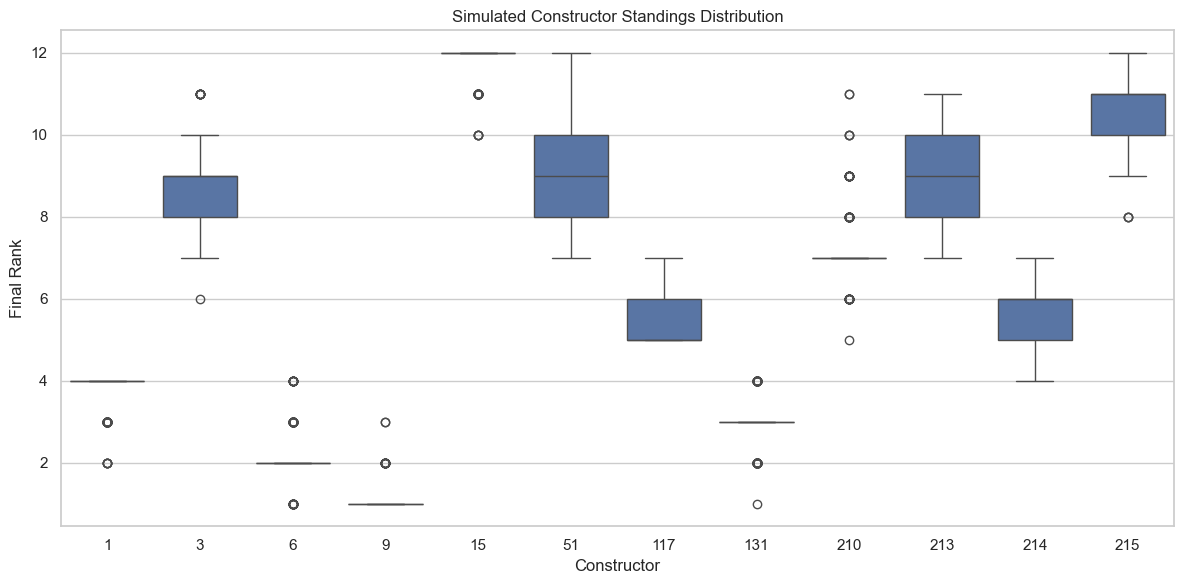

In [24]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=constructor_standings, x="constructorId", y="final_rank")
plt.title("Simulated Constructor Standings Distribution")
plt.xlabel("Constructor")
plt.ylabel("Final Rank")
plt.tight_layout()
plt.show()

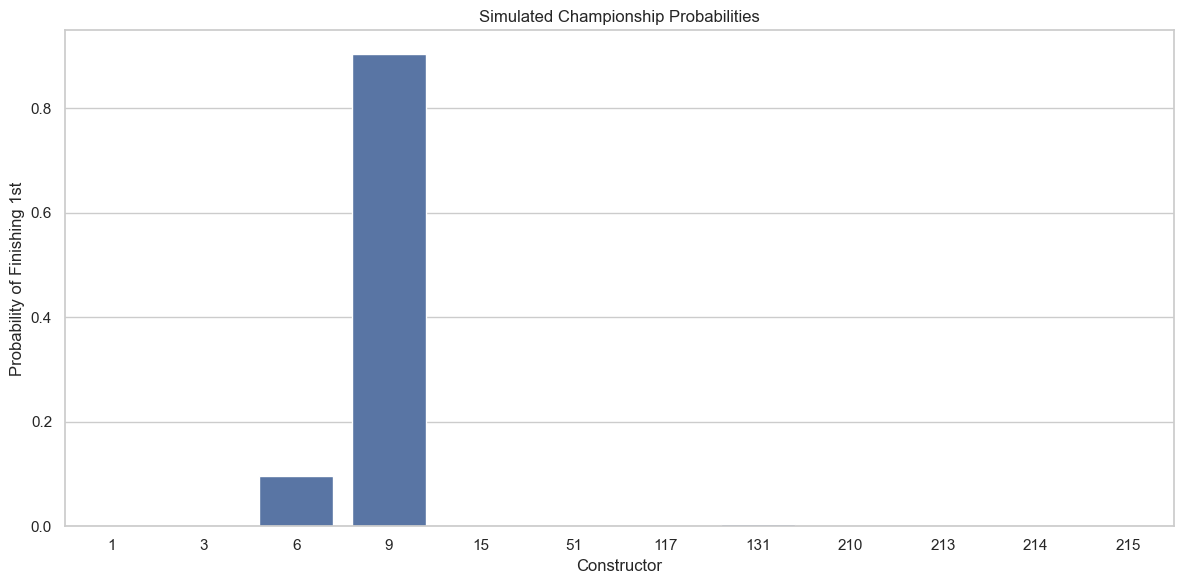

In [25]:
championship_prob = (
    constructor_standings
    .assign(champion=lambda d: (d["final_rank"] == 1).astype(int))
    .groupby("constructorId", as_index=False)
    .agg(championship_probability=("champion", "mean"))
)

plt.figure(figsize=(12, 6))
sns.barplot(data=championship_prob, x="constructorId", y="championship_probability")
plt.title("Simulated Championship Probabilities")
plt.xlabel("Constructor")
plt.ylabel("Probability of Finishing 1st")
plt.tight_layout()
plt.show()

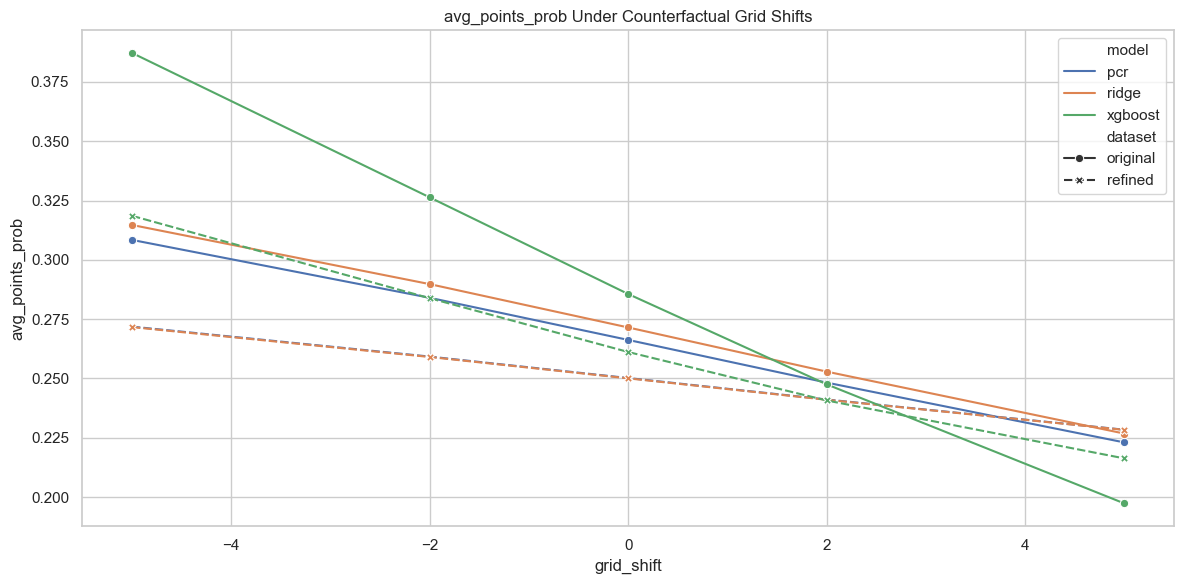

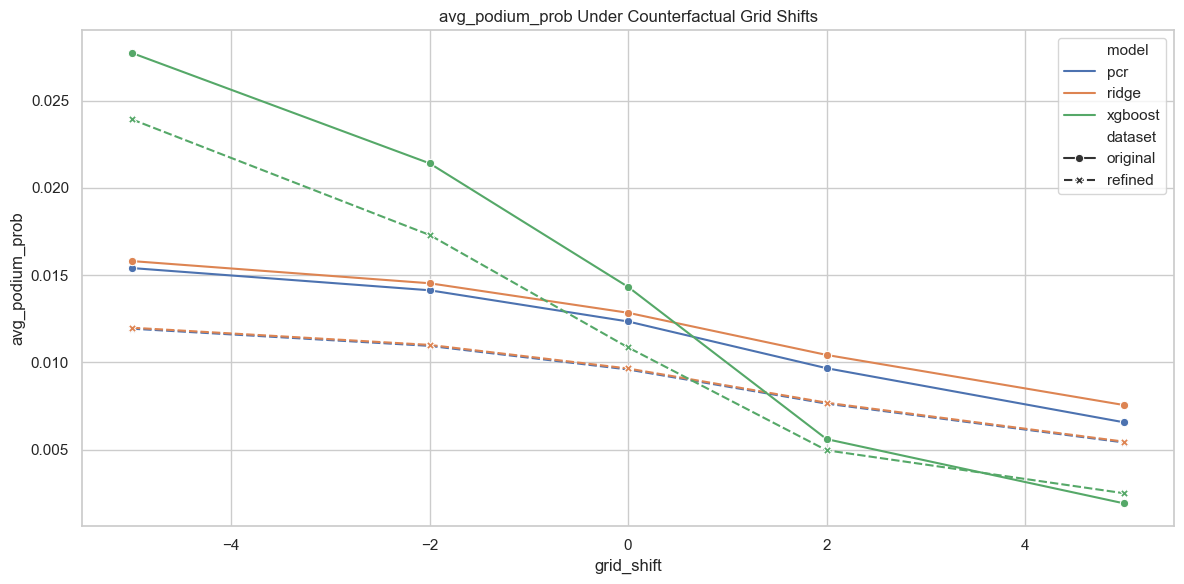

In [26]:
plot_df = (
    grid_shift_df
    .groupby(["target", "dataset", "model", "grid_shift"], as_index=False)
    .agg(
        avg_points_prob=("points_prob_proxy", "mean"),
        avg_podium_prob=("podium_prob_proxy", "mean")
    )
)

for metric in ["avg_points_prob", "avg_podium_prob"]:
    plt.figure(figsize=(12, 6))
    sns.lineplot(
        data=plot_df[plot_df["target"] == "finish_position"],
        x="grid_shift",
        y=metric,
        hue="model",
        style="dataset",
        markers=True
    )
    plt.title(f"{metric} Under Counterfactual Grid Shifts")
    plt.tight_layout()
    plt.show()

In [27]:
season_points = (
    baseline_sim
    .groupby(["sim", "raceId", "constructorId"], as_index=False)
    .agg(points=("sim_points", "sum"))
    .sort_values(["sim", "constructorId", "raceId"])
)

season_points["cum_points"] = season_points.groupby(["sim", "constructorId"])["points"].cumsum()

fan_df = (
    season_points
    .groupby(["raceId", "constructorId"])["cum_points"]
    .quantile([0.1, 0.5, 0.9])
    .unstack()
    .reset_index()
)
fan_df.columns = ["raceId", "constructorId", "p10", "p50", "p90"]
fan_df.head()

,raceId,constructorId,p10,p50,p90
0,1074,1,0.0,0.0,12.0
1,1074,3,0.0,0.0,12.0
2,1074,6,4.0,25.0,43.7
3,1074,9,0.0,15.0,35.0
4,1074,51,0.0,0.0,17.1


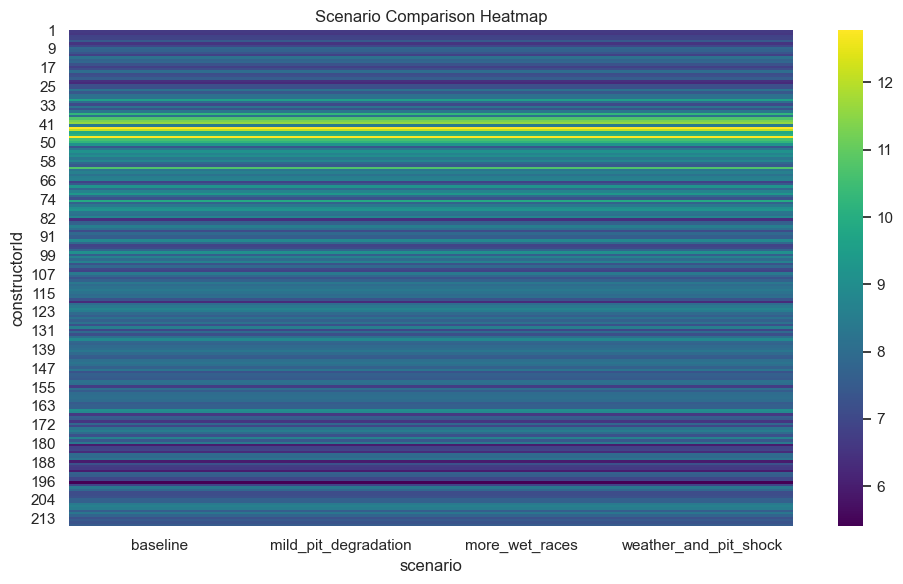

In [28]:
heatmap_df = (
    shock_df
    .groupby(["scenario", "constructorId"], as_index=False)
    .agg(avg_pred=("pred", "mean"))
    .pivot(index="constructorId", columns="scenario", values="avg_pred")
)

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_df, annot=False, cmap="viridis")
plt.title("Scenario Comparison Heatmap")
plt.tight_layout()
plt.show()

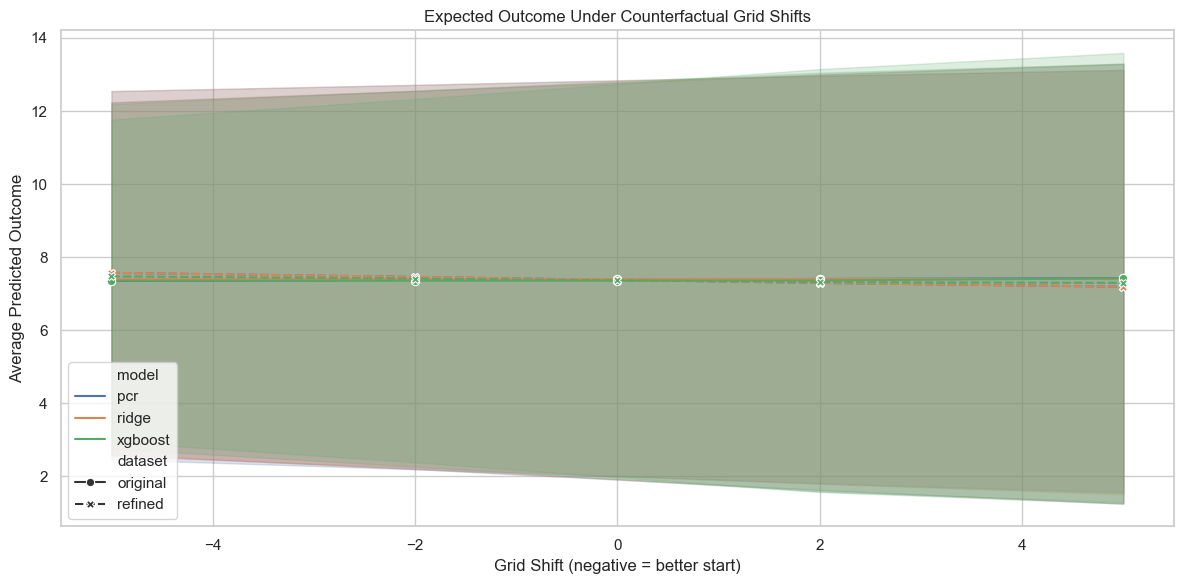

In [29]:
uplift_df = (
    grid_shift_df
    .groupby(["target", "dataset", "model", "grid_shift"], as_index=False)
    .agg(avg_pred=("pred", "mean"))
)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=uplift_df,
    x="grid_shift",
    y="avg_pred",
    hue="model",
    style="dataset",
    markers=True
)
plt.title("Expected Outcome Under Counterfactual Grid Shifts")
plt.xlabel("Grid Shift (negative = better start)")
plt.ylabel("Average Predicted Outcome")
plt.tight_layout()
plt.show()

## Instrumental Variables: A Possible Future Direction

A fully causal interpretation of counterfactual starting positions would require stronger identification than is currently available in this dataset.

One possible future direction is to explore instrumental variables based on exogenous grid shocks, such as penalties or irregular qualifying disruptions. However, a credible instrument would need to affect starting position without directly affecting race outcomes through other channels.

At this stage, the notebook focuses on predictive counterfactuals rather than fully identified causal estimates.

Potentially:

- weather shock affecting qualifying or starting position but not race outcome except through starting position
** hard to defend because weather likely affects race outcomes directly too.

Another possible instrument:

- qualifying penalties / grid penalties
** may correlate with team reliability or strategy, so also not clean.

## Must-have visuals
1. Simulated constructor standings distribution
violin / box plots by scenario
2. Championship probability bars
baseline vs reliability scenarios
3. Points / podium probability change under grid shifts
line plot of probability vs starting position change
4. Season simulation fan chart
simulated points trajectories
5. Scenario comparison heatmap
constructors × scenarios
6. Counterfactual uplift plot
expected points gain from better starting positions

## Overarching Question

**How much of a season is shaped by what should have happened, and how much changes when we intervene on starting position, reliability, or race-day shocks?**

## Connecting Back to the Broader Project

This notebook builds on earlier work in the project:

- distribution analysis showed that the data is not well-behaved
- model comparison revealed tradeoffs between interpretability and performance
- resampling highlighted instability and sensitivity to data splits

Simulation brings these ideas together by showing:

- how uncertainty propagates through the system
- how model assumptions behave under stress
- and where the data fails to fully describe reality

This creates a natural bridge to the next phase of the project, which will focus on:

- probabilistic modeling
- scenario optimization
- and decision-oriented analysis